### Data Setup

In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("../data/Coffee Shop Sales.csv")

In [3]:
# Convert transaction_date to datetime for time series analysis
df["transaction_date"] = pd.to_datetime(df["transaction_date"], format="%d-%m-%Y", errors="coerce")

In [4]:
# Add transaction price column
df["transaction_price"]=df["transaction_qty"]*df["unit_price"]

In [5]:
# Aggregate sales quantity per day
df_daily = df.groupby('transaction_date').agg({'transaction_price': 'sum'}).reset_index()

print(df_daily.head())

  transaction_date  transaction_price
0       2023-01-01            2508.20
1       2023-01-02            2403.35
2       2023-01-03            2565.00
3       2023-01-04            2220.10
4       2023-01-05            2418.85


In [6]:
# Set 'transaction_date' as index
df_daily.set_index('transaction_date', inplace=True)

In [7]:
# Create time-based features using 'transaction_date'
def create_features(df_daily):
    df_daily = df_daily.copy()
    df_daily['day'] = df_daily.index.day
    df_daily['month'] = df_daily.index.month
    df_daily["quarter"] = df_daily.index.quarter
    df_daily['day_of_week'] = df_daily.index.dayofweek
    df_daily['day_of_year'] = df_daily.index.dayofyear
    df_daily['week_of_year'] = df_daily.index.isocalendar().week
    return df_daily

df_daily = create_features(df_daily)


In [8]:
df_daily.head()

,transaction_price,day,month,quarter,day_of_week,day_of_year,week_of_year
transaction_date,,,,,,,
2023-01-01,2508.20,1,1,1,6,1,52
2023-01-02,2403.35,2,1,1,0,2,1
2023-01-03,2565.00,3,1,1,1,3,1
2023-01-04,2220.10,4,1,1,2,4,1
2023-01-05,2418.85,5,1,1,3,5,1


### Create Input Sequences for LSTM

In [9]:
# Function to create sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data.iloc[i:i + seq_length].values)  # Extract sequences for X
        y.append(data.iloc[i + seq_length, 0])  # Extract target value (first column, adjust if needed)
    return np.array(X), np.array(y)


In [10]:
SEQ_LENGTH = 3  # 3-day sequence
df_lstm=df_daily.copy()
df_lstm = df_lstm.reset_index(drop=True)
df_lstm['week_of_year'] = df_lstm['week_of_year'].astype('int32')
# Convert all columns in df_lstm to numeric, coercing any errors (e.g., non-numeric values) to NaN
df_lstm = df_lstm.apply(pd.to_numeric, errors='coerce')

# Check the data types 
print(df_lstm.dtypes)

transaction_price    float64
day                    int32
month                  int32
quarter                int32
day_of_week            int32
day_of_year            int32
week_of_year           int32
dtype: object


In [11]:
# Create sequences
X, y = create_sequences(df_lstm, SEQ_LENGTH)

### Train-Test Split

In [12]:
# Split the dataset into train and test (last 30 days for testing)
X_train, X_test = X[:-30], X[-30:]
y_train, y_test = y[:-30], y[-30:]

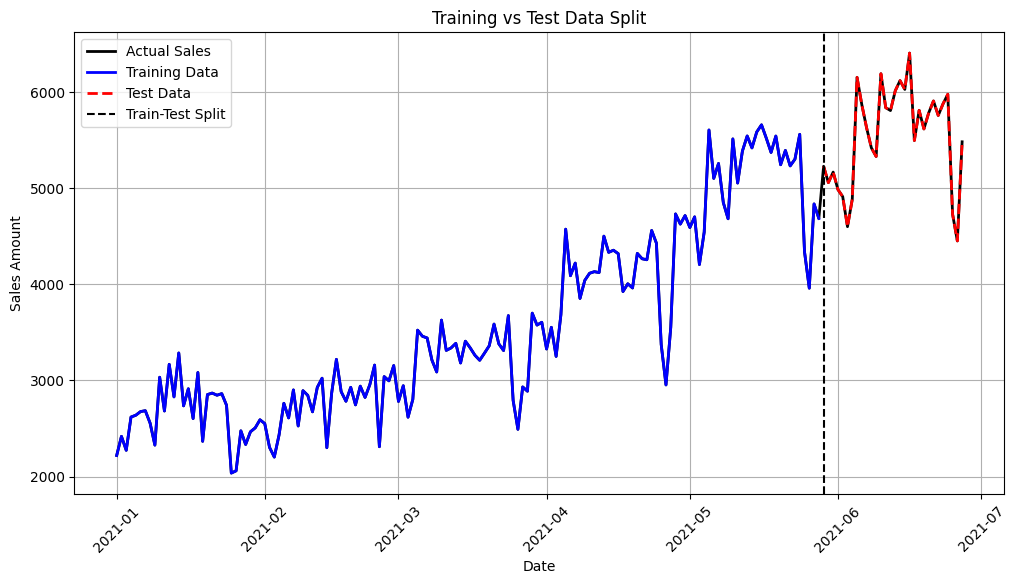

In [13]:
import matplotlib.pyplot as plt

# Create a time index for the data points
dates = pd.date_range(start="2021-01-01", periods=len(X), freq='D')  # Adjust the start date and frequency as per your dataset

# Plot the entire dataset
plt.figure(figsize=(12, 6))
plt.plot(dates, y, label="Actual Sales", color="black", linewidth=2)

# Split the dataset into train and test
train_dates = dates[:-30]
test_dates = dates[-30:]
train_sales = y[:-30]
test_sales = y[-30:]

# Plot the training data
plt.plot(train_dates, train_sales, label="Training Data", color="blue", linewidth=2)

# Plot the test data
plt.plot(test_dates, test_sales, label="Test Data", color="red", linestyle="dashed", linewidth=2)

# Add a vertical line to show the split
split_date = test_dates[0]  # First date of the test set
plt.axvline(x=split_date, color="black", linestyle="--", label="Train-Test Split")

# Formatting
plt.xlabel("Date")
plt.ylabel("Sales Amount")
plt.title("Training vs Test Data Split")
plt.xticks(rotation=45)  # Rotate x-axis labels
plt.legend(loc="best")
plt.grid(True)

# Show plot
plt.show()


### Scaling Features

In [14]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the scaler for X (input features)
scaler_X = MinMaxScaler()

# Initialize the scaler for y (target variable)
scaler_y = MinMaxScaler()

# Scale only the 'transaction_price' feature in X
X_train_scaled = X_train.copy()  # Create a copy of X_train
X_test_scaled = X_test.copy()    # Create a copy of X_test

# Apply MinMaxScaler to 'transaction_price' (assuming it's the first feature)
X_train_scaled[:, :, 0] = scaler_X.fit_transform(X_train[:, :, 0])  # Scale transaction_price in training data
X_test_scaled[:, :, 0] = scaler_X.transform(X_test[:, :, 0])        # Scale transaction_price in test data

# Now, scale the target variable y (transaction_qty)
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))  # Reshape y_train to 2D and scale
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))        # Reshape y_test to 2D and scale

# Your X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled are now ready for model training


In [15]:
X_train_scaled.shape

(148, 3, 7)

In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

### Model Definition & Training

In [17]:
# Define the LSTM model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(25, activation='relu'))
model.add(Dense(1))  # Predicting 'transaction_price'

# Compile the model
model.compile(optimizer='adam', loss='mse')

d:\AI Course\Second Semester\Capstone 2\Capstone-2\capstone-env\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [18]:
# Train the model
history = model.fit(X_train_scaled, y_train_scaled, epochs=30, batch_size=8, validation_data=(X_test_scaled, y_test_scaled))

# Display model summary
model.summary()

Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 0.0935 - val_loss: 0.1738
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0435 - val_loss: 0.0924
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0248 - val_loss: 0.0810
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0226 - val_loss: 0.0532
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0184 - val_loss: 0.0156
Epoch 6/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0170 - val_loss: 0.0142
Epoch 7/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0168 - val_loss: 0.0157
Epoch 8/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0189 - val_loss: 0.0185
Epoch 9/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0146 - val_loss: 0.0277
Epoch 10/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0119 - val_loss: 0.0198
Epoch 11/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0125 - val_loss: 0.0180
Epoch 12/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0123 -

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 3, 50)          │        11,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 99,305 (387.91 KB)

 Trainable params: 33,101 (129.30 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 66,204 (258.61 KB)

### Model Evaluation

In [19]:
# Evaluate model
y_pred = model.predict(X_test_scaled)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step


📊 Model Performance Metrics:
MAE: 341.22
RMSE: 469.59
R² Score: 0.1324
MAPE: 6.60%


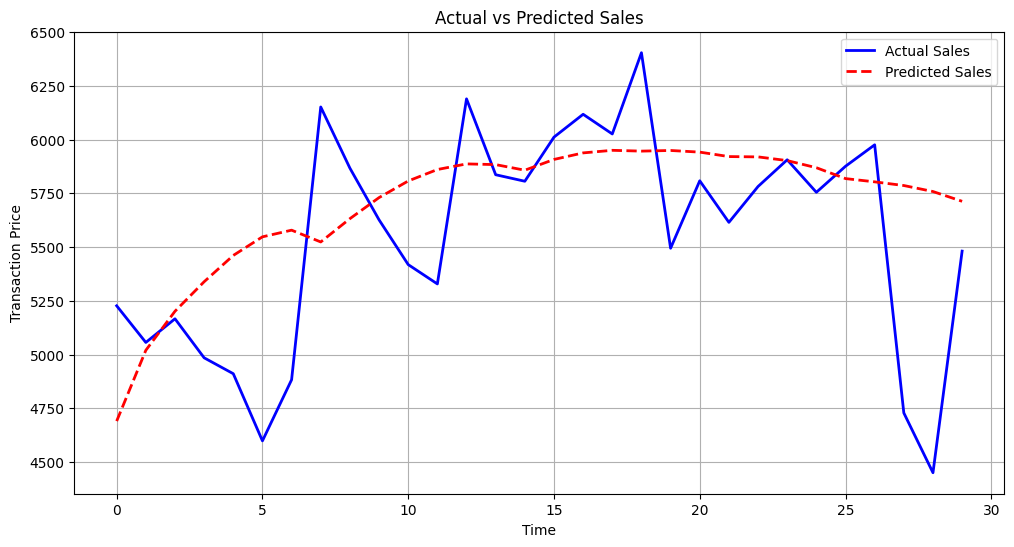

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Convert predictions back to the original scale (transaction_price) using scaler_y
y_test_actual = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1))
y_pred_actual = scaler_y.inverse_transform(y_pred.flatten().reshape(-1, 1))

# Calculate Model Evaluation Metrics
mae = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
r2 = r2_score(y_test_actual, y_pred_actual)

# Calculate Mean Absolute Percentage Error (MAPE)
mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100

# Print Metrics
print(f"📊 Model Performance Metrics:")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

# Plot Actual vs Predicted Values
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label='Actual Sales', color='blue', linewidth=2)
plt.plot(y_pred_actual, label='Predicted Sales', color='red', linestyle='dashed', linewidth=2)
plt.xlabel("Time")
plt.ylabel("Transaction Price")
plt.title("Actual vs Predicted Sales")
plt.legend()
plt.grid(True)
plt.show()


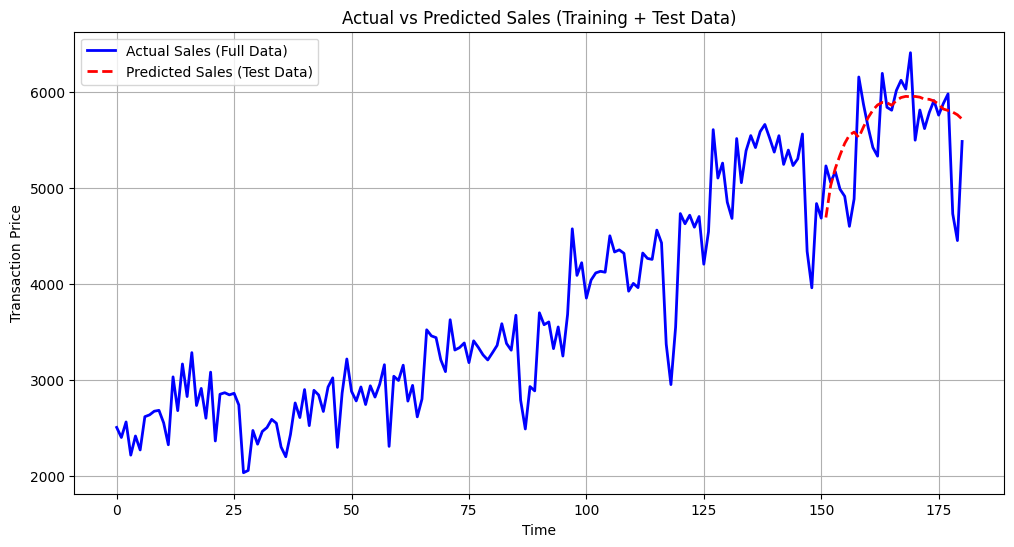

In [21]:
# Plot Entire Data (Training + Test Data) and Predicted Sales

plt.figure(figsize=(12, 6))

# Plot the actual sales for the entire dataset (train + test)
plt.plot(np.arange(len(df_lstm['transaction_price'])), df_lstm['transaction_price'], label='Actual Sales (Full Data)', color='blue', linewidth=2)

# Plot the predicted sales for the test data
plt.plot(np.arange(len(y_test_actual)) + len(df_lstm) - len(y_test_actual), y_pred_actual, label='Predicted Sales (Test Data)', color='red', linestyle='dashed', linewidth=2)

# Add labels and title
plt.xlabel("Time")
plt.ylabel("Transaction Price")
plt.title("Actual vs Predicted Sales (Training + Test Data)")
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

In [22]:
import numpy as np
import pandas as pd

def extract_time_features(dates):
    """Extracts time-based features for given dates."""
    features = []
    for date in dates:
        dt = pd.to_datetime(date)
        features.append([
            dt.day,         # Day of month
            dt.month,       # Month
            (dt.month - 1) // 3 + 1,  # Quarter
            dt.dayofweek,   # Day of week (0 = Monday, 6 = Sunday)
            dt.dayofyear,   # Day of year
            dt.isocalendar()[1],  # Week of year
        ])
    return np.array(features)  # Shape: (num_future_days, 6)

def predict_future(model, X_test_scaled, H, last_date):
    """
    Predicts future sales for the next H days.

    Parameters:
    - model: Trained LSTM model.
    - X_test_scaled: Scaled test data (num_sequences, sequence_length, num_features).
    - H: Number of future days to predict.
    - last_date: The last known date in the dataset.

    Returns:
    - future_preds: Scaled future predictions.
    """
    future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=H)
    time_features = extract_time_features(future_dates)  # Shape: (H, 6)

    last_input = X_test_scaled[-1].reshape(1, 3, -1)  # Get last sequence (1, 3, 7)
    future_preds = []

    for i in range(H):
        pred_scaled = model.predict(last_input)  # Predict next day (already scaled)
        future_preds.append(pred_scaled[0, 0])  # Store scaled prediction

        # Prepare new input for the next prediction
        new_features = np.hstack([pred_scaled.reshape(1, -1), time_features[i].reshape(1, -1)])  # Shape (1, 7)

        # Shift sequence (remove oldest time step, add new one)
        new_input = np.zeros_like(last_input)  
        new_input[:, :-1, :] = last_input[:, 1:, :]  # Shift left
        new_input[:, -1, :] = new_features  # Add new prediction + time features

        last_input = new_input  # Update for next step

    return future_dates, future_preds

# Example usage
H = 7  # Forecast next 7 days
last_date = pd.Timestamp("2023-06-30")
future_dates, future_sales_scaled = predict_future(model, X_test_scaled, H, last_date)

# Convert back to original scale only for final output
future_sales = scaler_y.inverse_transform(np.array(future_sales_scaled).reshape(-1, 1)).flatten()

# Print predictions with dates
for date, pred in zip(future_dates, future_sales):
    print(f"{date.date()} -> Predicted Sales: {pred}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
2023-07-01 -> Predicted Sales: 5712.92919921875
2023-07-02 -> Predicted Sales: 5765.85791015625
2023-07-03 -> Predicted Sales: 5684.505859375
2023-07-04 -> Predicted Sales: 5630.16015625
2023-07-05 -> Predicted Sales: 5671.8388671875
2023-07-06 -> Predicted Sales: 5604.4697265625
2023-07-07 -> Predicted Sales: 5701.34375


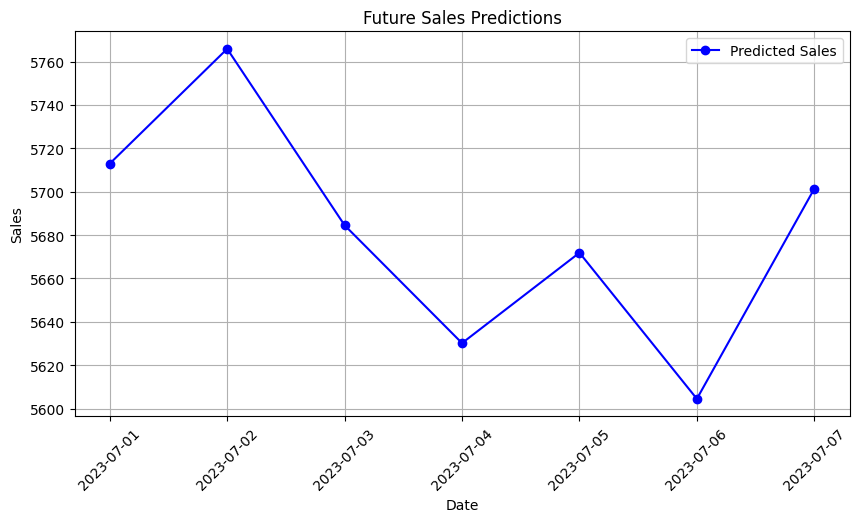

In [23]:
import matplotlib.pyplot as plt

# Plot predictions
plt.figure(figsize=(10, 5))
plt.plot(future_dates, future_sales, marker='o', linestyle='-', color='b', label="Predicted Sales")

# Formatting
plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Future Sales Predictions")
plt.xticks(rotation=45)
plt.legend()
plt.grid()

# Show plot
plt.show()


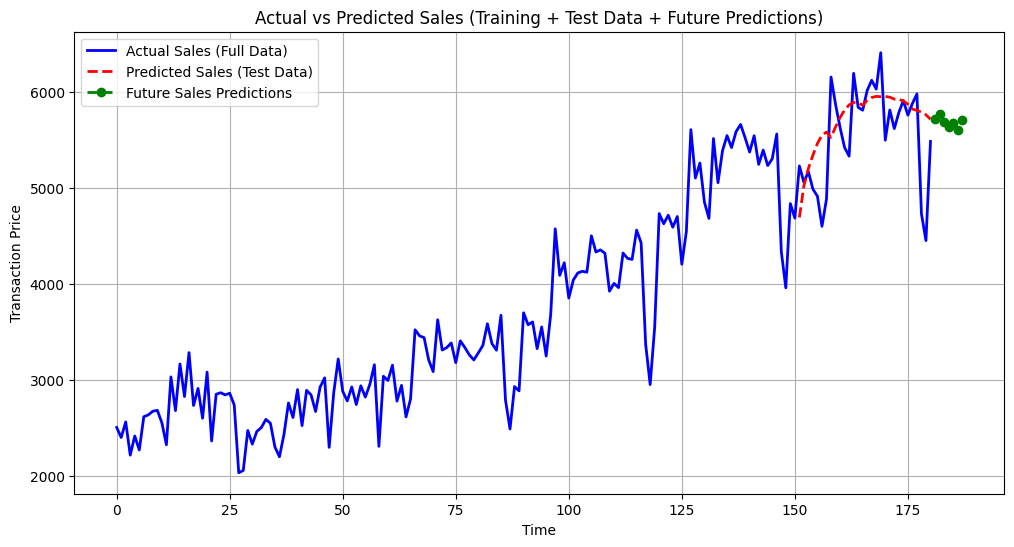

In [24]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6))

# Plot actual sales for the entire dataset (train + test)
plt.plot(np.arange(len(df_lstm['transaction_price'])), df_lstm['transaction_price'], label='Actual Sales (Full Data)', color='blue', linewidth=2)

# Plot predicted sales for the test data
plt.plot(np.arange(len(y_test_actual)) + len(df_lstm) - len(y_test_actual), y_pred_actual, label='Predicted Sales (Test Data)', color='red', linestyle='dashed', linewidth=2)

# Plot future sales predictions
plt.plot(np.arange(len(df_lstm), len(df_lstm) + len(future_sales)), future_sales, label='Future Sales Predictions', color='green', marker='o', linestyle='dashed', linewidth=2)

# Add labels and title
plt.xlabel("Time")
plt.ylabel("Transaction Price")
plt.title("Actual vs Predicted Sales (Training + Test Data + Future Predictions)")
plt.legend()
plt.grid(True)

# Show the plot
plt.show()


### Test Prediction Comparison

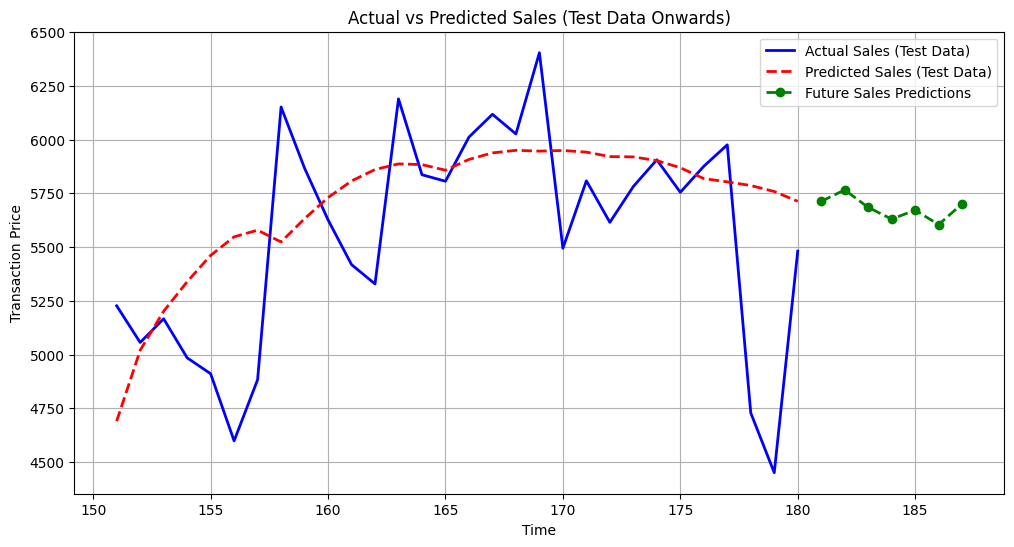

In [25]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6))

# Define starting index (where test data begins)
start_idx = len(df_lstm) - len(y_test_actual)

# Plot actual test data
plt.plot(np.arange(start_idx, len(df_lstm)), y_test_actual, label='Actual Sales (Test Data)', color='blue', linewidth=2)

# Plot predicted test data
plt.plot(np.arange(start_idx, len(df_lstm)), y_pred_actual, label='Predicted Sales (Test Data)', color='red', linestyle='dashed', linewidth=2)

# Plot future sales predictions
plt.plot(np.arange(len(df_lstm), len(df_lstm) + len(future_sales)), future_sales, label='Future Sales Predictions', color='green', marker='o', linestyle='dashed', linewidth=2)

# Add labels and title
plt.xlabel("Time")
plt.ylabel("Transaction Price")
plt.title("Actual vs Predicted Sales (Test Data Onwards)")
plt.legend()
plt.grid(True)

# Show the plot
plt.show()


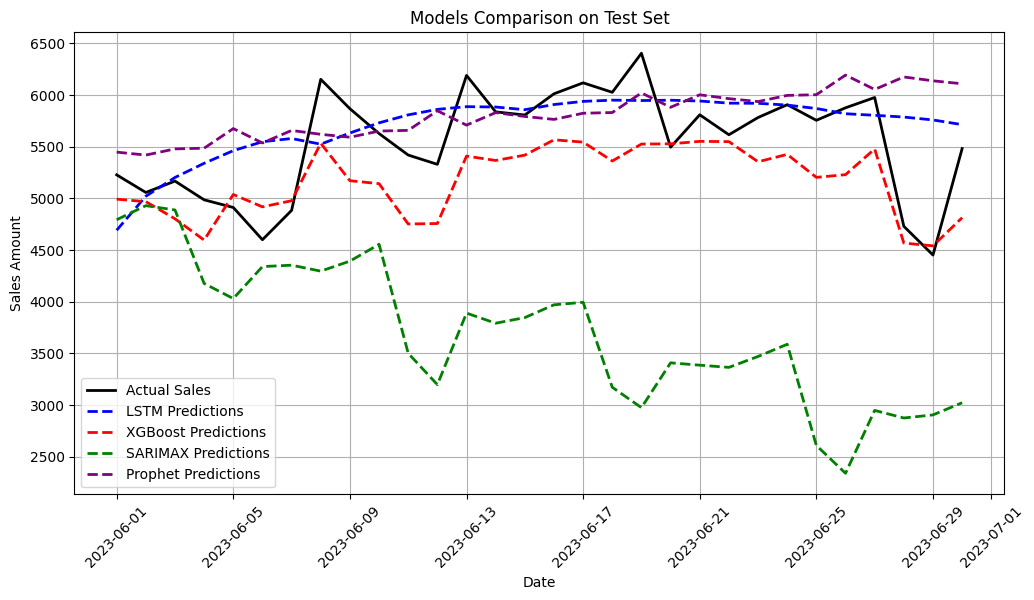

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Load predictions
sales_xgb = pd.read_csv("../data/sales_xgb.csv", parse_dates=["transaction_date"])
sales_sarimax = pd.read_csv("../data/sales_sarimax.csv", parse_dates=["transaction_date"])
sales_prophet = pd.read_csv("../data/sales_prophet.csv", parse_dates=["transaction_date"])  # Prophet CSV

# Use transaction_date for test set dates
test_dates = sales_xgb["transaction_date"]

# Plot actual sales
plt.figure(figsize=(12, 6))
plt.plot(test_dates, y_test_actual, label="Actual Sales", color="black", linewidth=2)

# Plot LSTM predictions
plt.plot(test_dates, y_pred_actual, label="LSTM Predictions", color="blue", linestyle="dashed", linewidth=2)

# Plot XGBoost predictions
plt.plot(sales_xgb["transaction_date"], sales_xgb["prediction"], label="XGBoost Predictions", color="red", linestyle="dashed", linewidth=2)

# Plot SARIMAX predictions
plt.plot(sales_sarimax["transaction_date"], sales_sarimax["prediction"], label="SARIMAX Predictions", color="green", linestyle="dashed", linewidth=2)

# Plot Prophet predictions
plt.plot(sales_prophet["transaction_date"], sales_prophet["prediction"], label="Prophet Predictions", color="purple", linestyle="dashed", linewidth=2)

# Formatting
plt.xlabel("Date")
plt.ylabel("Sales Amount")
plt.title("Models Comparison on Test Set")
plt.xticks(rotation=45)  # Rotate x-axis labels
plt.legend(loc="best")   # Show legend
plt.grid(True)

# Show plot
plt.show()


### Future Prediction Comparison

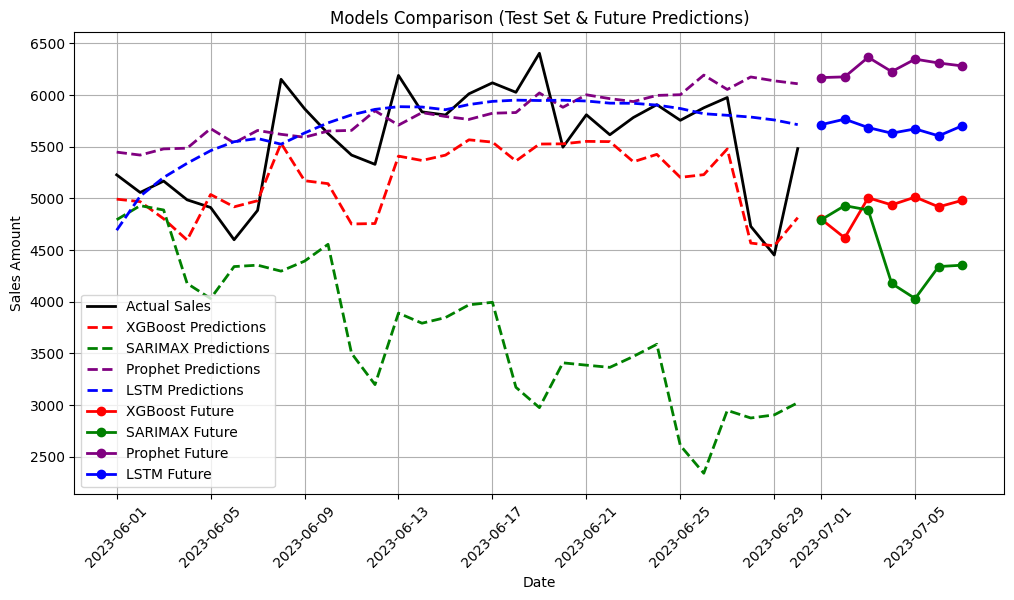

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Load past predictions (test set) from CSVs
sales_xgb = pd.read_csv("../data/sales_xgb.csv", parse_dates=["transaction_date"])
sales_sarimax = pd.read_csv("../data/sales_sarimax.csv", parse_dates=["transaction_date"])
sales_prophet = pd.read_csv("../data/sales_prophet.csv", parse_dates=["transaction_date"])

# Load future predictions from CSVs
future_xgb = pd.read_csv("../data/future_xgb.csv", parse_dates=["date"])
future_sarimax = pd.read_csv("../data/future_sarimax.csv", parse_dates=["date"])
future_prophet = pd.read_csv("../data/future_prophet.csv", parse_dates=["date"])

# LSTM predictions (from the notebook)
# Hardcoded start date for actual and predicted sales
start_date = pd.to_datetime("2023-06-01")

# Create date range for the test data (30 days)
test_dates = pd.date_range(start=start_date, periods=30, freq='D')

# Create date range for the future predictions (7 days)
future_dates = pd.date_range(start=test_dates[-1] + pd.Timedelta(days=1), periods=7, freq='D')

# Assuming y_test_actual, y_pred_actual, and future_sales data are already defined in your notebook
# LSTM test predictions are stored in y_pred_actual, and actual sales are stored in y_test_actual
# Future sales predictions from LSTM are stored in future_sales

# Create figure
plt.figure(figsize=(12, 6))

# Plot actual sales (test data)
plt.plot(test_dates, y_test_actual, label="Actual Sales", color="black", linewidth=2)

# Plot test set predictions (dashed lines)
plt.plot(sales_xgb["transaction_date"], sales_xgb["prediction"], label="XGBoost Predictions", color="red", linestyle="dashed", linewidth=2)
plt.plot(sales_sarimax["transaction_date"], sales_sarimax["prediction"], label="SARIMAX Predictions", color="green", linestyle="dashed", linewidth=2)
plt.plot(sales_prophet["transaction_date"], sales_prophet["prediction"], label="Prophet Predictions", color="purple", linestyle="dashed", linewidth=2)

# Plot LSTM predictions (dashed lines) for test data
plt.plot(test_dates, y_pred_actual, label="LSTM Predictions", color="blue", linestyle="dashed", linewidth=2)

# Plot future predictions (solid lines) with markers
plt.plot(future_xgb["date"], future_xgb["future"], label="XGBoost Future", color="red", linewidth=2, marker='o', markersize=6)
plt.plot(future_sarimax["date"], future_sarimax["future"], label="SARIMAX Future", color="green", linewidth=2, marker='o', markersize=6)
plt.plot(future_prophet["date"], future_prophet["future"], label="Prophet Future", color="purple", linewidth=2, marker='o', markersize=6)

# Plot LSTM future predictions (solid line with markers)
plt.plot(future_dates, future_sales, label="LSTM Future", color="blue", linewidth=2, marker='o', markersize=6)

# Formatting
plt.xlabel("Date")
plt.ylabel("Sales Amount")
plt.title("Models Comparison (Test Set & Future Predictions)")
plt.xticks(rotation=45)  # Rotate x-axis labels
plt.legend(loc="best")   # Show legend
plt.grid(True)

# Show the plot
plt.show()
